## Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Data Load and exploration

Loading from: /Users/luissolis/Desktop/ETIM/Seminar/log_regression/Data/final.csv
Loading from: /Users/luissolis/Desktop/ETIM/Seminar/log_regression/Data/final.csv
Filtered by age: kept 81 of 1755 rows
Shape: (81, 113)

Target distribution (target_pro_success):
target_pro_success
1.0    0.55
0.0    0.45
Name: proportion, dtype: float64

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 81 entries, 0 to 80
Columns: 113 entries, id to target_pro_success
dtypes: float64(76), int64(5), object(32)
memory usage: 72.1+ KB
None

=== MISSING VALUES (non-zero only) ===
hst_injury_count_12_16    80
hst_days_missed_2y        80
hst_comp_level            80
hst_age_first_at_level    80
le_watt                   67
shuttle_100yd             66
ue_watt                   65
pull_ups                  61
shuttle_150yd             56
shuttle_300yd             54
flexed_arm_hang           27
weight                    25
vertical_jump              8
height                     8
dash_10yd           

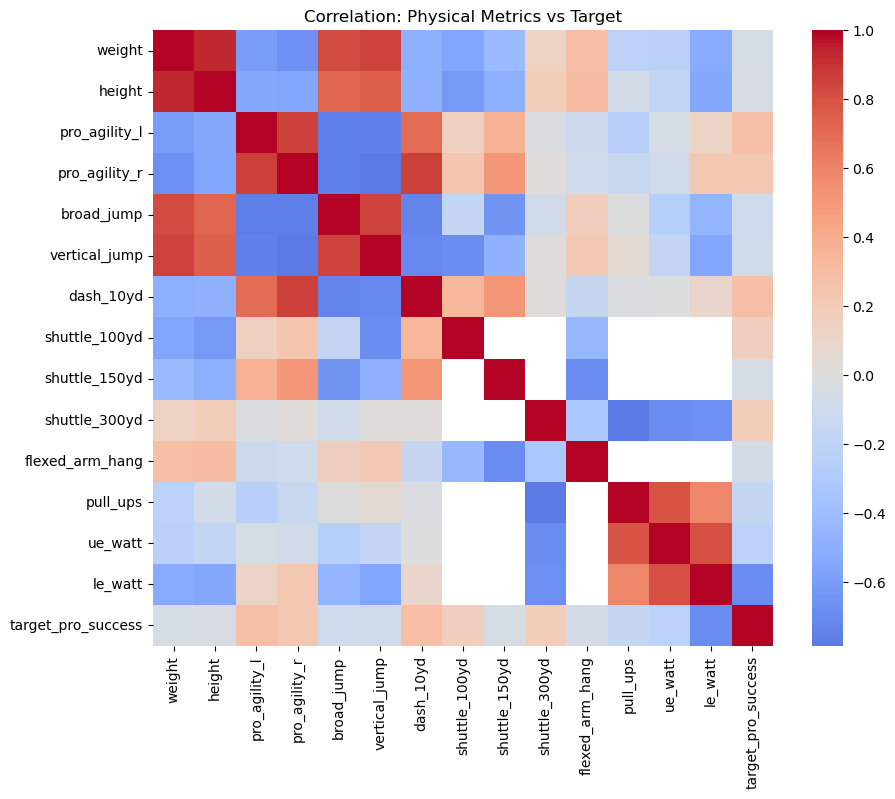

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === PATHS ===
project_root = '/Users/luissolis/Desktop/ETIM/Seminar/log_regression'
data_path = os.path.join(project_root, 'Data', 'final.csv')

print("Loading from:", data_path)
df = pd.read_csv(data_path)

print("Loading from:", data_path)
df = pd.read_csv(data_path)

# --- FILTER TO ROWS WITH AGE PRESENT ---
df = df.copy()
before = df.shape[0]
df = df[df['age'].notna()].copy()
after = df.shape[0]
print(f"Filtered by age: kept {after} of {before} rows")



# === BASIC INFO ===
print("Shape:", df.shape)
print("\nTarget distribution (target_pro_success):")
print(df['target_pro_success'].value_counts(normalize=True))

print("\n=== INFO ===")
print(df.info())

print("\n=== MISSING VALUES (non-zero only) ===")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print("\n=== NUMERIC SUMMARY ===")
print(df.describe().T.round(2))

print("\n=== CATEGORICAL EXAMPLE COUNTS ===")
for col in ['gender', 'category', 'demo_edu', 'demo_income']:
    if col in df.columns:
        print(f"\n{col} value counts:")
        print(df[col].value_counts(dropna=False))

# === PHYSICAL METRICS CORRELATION ===
physical_cols = [
    'weight', 'height', 'pro_agility_l', 'pro_agility_r', 'broad_jump', 'vertical_jump',
    'dash_10yd', 'shuttle_100yd', 'shuttle_150yd', 'shuttle_300yd',
    'flexed_arm_hang', 'pull_ups', 'ue_watt', 'le_watt'
]

# CLEAN non-numeric markers (e.g., 'x') in physical columns
for col in physical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

cols_for_corr = [c for c in physical_cols + ['target_pro_success'] if c in df.columns]
corr = df[cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation: Physical Metrics vs Target')
plt.show()


## Preprocessing and feature selection

In [9]:
import numpy as np

## ---------- PREPROCESSING SETUP ----------

# 1) Drop identifier and target split
df_ml = df.drop(columns=['id'], errors='ignore')              # id is not a predictor
target_col = 'target_pro_success'
y = df_ml[target_col]
X = df_ml.drop(columns=[target_col], errors='ignore')

print(f"Target before cleanup: {y.shape[0]} rows")
print(f"Target NaNs: {y.isna().sum()} ({y.isna().sum()/len(y)*100:.1f}%)")

# Drop rows where target is missing
mask = ~y.isna()
y = y[mask]
df_ml = df_ml[mask]
X = df_ml.drop(columns=[target_col], errors='ignore')

print(f"Target after cleanup: {y.shape[0]} rows (dropped {y.shape[0] - len(y)})")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")
print("✅ Target NaNs fixed")

# 2) Drop low-quality / unused history fields
X = X.drop(
    columns=[
        'hst_injury_count_12_16',
        'hst_days_missed_2y',
        'hst_comp_level',
        'hst_age_first_at_level'
    ],
    errors='ignore'
)

# 3) Clean percentage strings in *_rel_impr_pct columns
pct_cols = [c for c in X.columns if c.endswith('_rel_impr_pct')]
for col in pct_cols:
    X[col] = (
        X[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .replace('', np.nan)
    )
    X[col] = pd.to_numeric(X[col], errors='coerce')

# 4) Physical metric base columns
physical_cols = [
    'weight', 'height', 'pro_agility_l', 'pro_agility_r', 'broad_jump', 'vertical_jump',
    'dash_10yd', 'shuttle_100yd', 'shuttle_150yd', 'shuttle_300yd',
    'flexed_arm_hang', 'pull_ups', 'ue_watt', 'le_watt'
]

# 5) Ensure physicals are numeric
for col in physical_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# 6) Improvement / trajectory columns
improvement_cols = [
    c for c in X.columns
    if any(x in c for x in ['_abs_impr', '_rel_impr_pct', '_impr_per_year'])
]

# 7) Continuous / ordinal numeric features (z-scored later)
num_features = [
    # demographics & context
    'birth_year', 'gender', 'category', 'age',
    'demo_edu', 'demo_income', 'demo_fin_support',
    'demo_sports_access', 'demo_years_org_sport',

    # psych composites
    'mtq_score', 'grt_score', 'res_score', 'se_score',
    'sms_core', 'twc_score',
    'cog_focus_score', 'sleep_hrs_band',
    'nut_score', 'nut_energy_mornings',
    'cog_decision_intelligence_score', 'cog_pregame_anxiety',
    'coach_score',

    # hockey history & load
    'hst_age_first_league', 'hst_age_regular_hky', 'hst_age_supervised',
    'hst_age_main_sport',
    'hst_practice_hrs_band', 'hst_game_hrs_band',
    'hst_multi_sport_level', 'hst_effort', 'hst_focus',
    'hst_enjoyment', 'hst_camps_freq',

    # physical baseline
    'weight', 'height', 'pro_agility_l', 'pro_agility_r',
    'broad_jump', 'vertical_jump', 'dash_10yd',
    'shuttle_100yd', 'shuttle_150yd', 'shuttle_300yd',
    'flexed_arm_hang', 'pull_ups', 'ue_watt', 'le_watt',

    # testing history
    'category_progression', 'num_tests'
] + improvement_cols

num_features = [c for c in num_features if c in X.columns]

# Binary indicator features (0/1, no scaling)
binary_features = [
    'demo_race_asian', 'demo_race_black', 'demo_race_hispanic',
    'demo_race_native', 'demo_race_pacific', 'demo_race_white',
    'hst_hky_8plus_months', 'hst_relocated',
    'nut_balanced_meals', 'nut_limiting_factors',
    'cop_breathing_exercises', 'cop_self_talk',
    'cop_visualization', 'cop_talking_to_teammate', 'cop_other',
    'ever_promoted_between_tests'
]
binary_features = [c for c in binary_features if c in X.columns]

print("Numeric features:", len(num_features))
print("Binary features:", len(binary_features))

## ---------- IMPUTATION & ENCODING ----------

# 8) Measured flags for heavily-missing tests
heavy_missing_cols = [
    'shuttle_100yd', 'shuttle_150yd', 'shuttle_300yd',
    'flexed_arm_hang', 'pull_ups', 'ue_watt', 'le_watt'
]
for col in heavy_missing_cols:
    if col in X.columns:
        X[col + '_measured'] = (~X[col].isna()).astype(int)

# 9) Group-wise median imputation for heavy-missing tests
group_cols = [c for c in ['category', 'gender'] if c in X.columns]
for col in heavy_missing_cols:
    if col in X.columns:
        if group_cols:
            X[col] = X.groupby(group_cols)[col].transform(
                lambda s: s.fillna(s.median())
            )
        X[col] = X[col].fillna(X[col].median())

# 10) Numeric imputer
num_imputer = SimpleImputer(strategy='median')

# Fill binaries: missing → 0
if binary_features:
    X[binary_features] = X[binary_features].fillna(0).astype(int)

# 11) Final numeric feature list including measured flags
num_features_full = list(set(
    num_features +
    [c + '_measured' for c in heavy_missing_cols if c + '_measured' in X.columns]
))
num_features_full = [c for c in num_features_full if c in X.columns]

# 12) Impute numeric features
X[num_features_full] = num_imputer.fit_transform(X[num_features_full])

# 13) (Optional) Encode gender & category if not already numeric
# If they are already numeric in the CSV you can comment this block out.
le_gender = LabelEncoder()
if 'gender' in X.columns and X['gender'].dtype == 'object':
    X['gender'] = le_gender.fit_transform(X['gender'].astype(str))

le_category = LabelEncoder()
if 'category' in X.columns and X['category'].dtype == 'object':
    X['category'] = le_category.fit_transform(X['category'].astype(str))

## ---------- FEATURE SELECTION INPUT MATRIX ----------

# 14) Build pure numeric matrix for SelectKBest
numeric_cols = num_features_full + binary_features
numeric_cols = [c for c in numeric_cols if c in X.columns]
X_num = X[numeric_cols].astype(float)

# 15) Univariate feature selection (ANOVA F-test)
#     k_anova controls how many features are kept after ANOVA screening.
k_anova = 50                           ## number of features to keep from ANOVA (cap)
selector = SelectKBest(
    score_func=f_classif,
    k=min(k_anova, X_num.shape[1])      ## ANOVA-selected feature count
)
X_selected = selector.fit_transform(X_num, y)
selected_features = X_num.columns[selector.get_support()].tolist()

# Build table of all F-scores for inspection
feature_scores = (
    pd.DataFrame({
        'feature': X_num.columns,
        'f_score': selector.scores_,
        'p_value': selector.pvalues_
    })
    .sort_values('f_score', ascending=False)
)

print("\nTop 15 features by ANOVA F-score:")   ## only printing best 15 for readability
print(feature_scores.head(15).round(4))

# 16) Selected feature dataframe (these k_anova features go into the model)
X_selected_df = pd.DataFrame(X_selected, columns=selected_features, index=X.index)




Target before cleanup: 81 rows
Target NaNs: 1 (1.2%)
Target after cleanup: 80 rows (dropped 0)
Target distribution:
target_pro_success
1.0    0.55
0.0    0.45
Name: proportion, dtype: float64
✅ Target NaNs fixed
Numeric features: 91
Binary features: 16

Top 15 features by ANOVA F-score:
                          feature  f_score  p_value
81    vertical_jump_impr_per_year  21.1425   0.0000
41  flexed_arm_hang_impr_per_year  17.1080   0.0001
65               demo_fin_support  15.6672   0.0002
85                       demo_edu  14.0718   0.0003
26           weight_impr_per_year  13.2600   0.0005
89            cog_pregame_anxiety  13.2314   0.0005
68       broad_jump_impr_per_year  13.2110   0.0005
3                  sleep_hrs_band  10.7941   0.0015
27       flexed_arm_hang_abs_impr  10.6714   0.0016
1      shuttle_100yd_rel_impr_pct   9.2968   0.0031
54         shuttle_100yd_abs_impr   8.8958   0.0038
30    shuttle_100yd_impr_per_year   8.5464   0.0045
82                      hst_focus   

## Training split

In [12]:
# ---------- TRAIN / TEST SPLIT + SCALING ----------
X_train, X_test, y_train, y_test = train_test_split(
    X_selected_df, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------- SIMILARITY PREP (uses same index as y / X_selected_df) ----------
X_all_scaled = scaler.transform(X_selected_df)  # all 80 rows in feature space
X_all_scaled_df = pd.DataFrame(
    X_all_scaled, columns=selected_features, index=X_selected_df.index
)

made_it_mask = (y == 1)

# Feature-space vectors for players who made it
X_made_it_scaled = X_all_scaled_df.loc[made_it_mask].values  # shape (N_pos, d)

# IDs aligned with the same filtered index
if 'id' in df.columns:
    # df must still have original ids; align by index used in X_selected_df/y
    id_series = df.loc[X_selected_df.index, 'id']
    made_it_ids = id_series.loc[made_it_mask].tolist()
else:
    made_it_ids = None

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))


Train shape: (64, 50)
Test shape: (16, 50)
Train target distribution:
 target_pro_success
1.0    0.546875
0.0    0.453125
Name: proportion, dtype: float64
Test target distribution:
 target_pro_success
1.0    0.5625
0.0    0.4375
Name: proportion, dtype: float64


## Model

In [13]:
## Model: Logistic Regression + small grid search

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Base logistic regression model
base_lr = LogisticRegression(
    random_state=42,
    max_iter=2000,
    solver='saga',             # supports l1 and l2 on large/sparse feature spaces [web:252]
    class_weight='balanced'    # keep to emphasize minority class even if ~55/45 [web:264]
)

# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.03, 0.1],         # regularization strength values to explore [web:252]
    'penalty': ['l1', 'l2']    # l1 for sparsity, l2 for ridge-style penalty [web:259]
    # l1_ratio is omitted because it is only used with penalty='elasticnet' [web:254]
}

# Stratified cross-validation to preserve class balance in folds
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Grid search with ROC-AUC scoring
grid_search = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

# Fit on scaled training data
grid_search.fit(X_train_scaled, y_train)

# Best model and performance
best_lr = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")


Best params: {'C': 0.1, 'penalty': 'l2'}
Best CV ROC-AUC: 0.9301


## Training and evals


=== TRAIN METRICS ===
Accuracy:  0.984
ROC-AUC:   0.999
Precision: 1.000
Recall:    0.971
F1-score:  0.986

Classification report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98        29
         1.0       1.00      0.97      0.99        35

    accuracy                           0.98        64
   macro avg       0.98      0.99      0.98        64
weighted avg       0.98      0.98      0.98        64


=== TEST METRICS ===
Accuracy:  0.938
ROC-AUC:   0.984
Precision: 1.000
Recall:    0.889
F1-score:  0.941

Classification report:
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.93         7
         1.0       1.00      0.89      0.94         9

    accuracy                           0.94        16
   macro avg       0.94      0.94      0.94        16
weighted avg       0.95      0.94      0.94        16



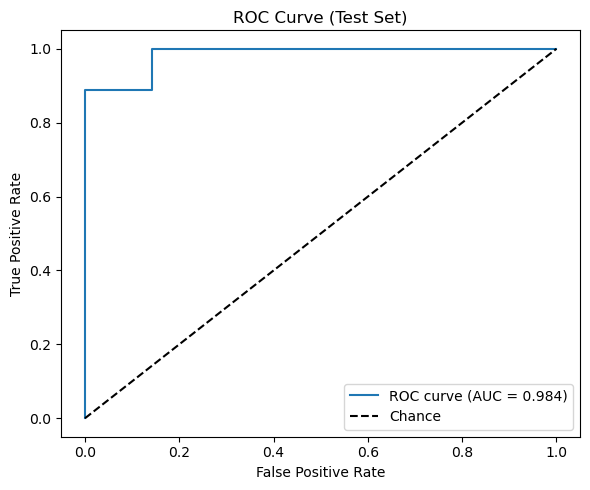

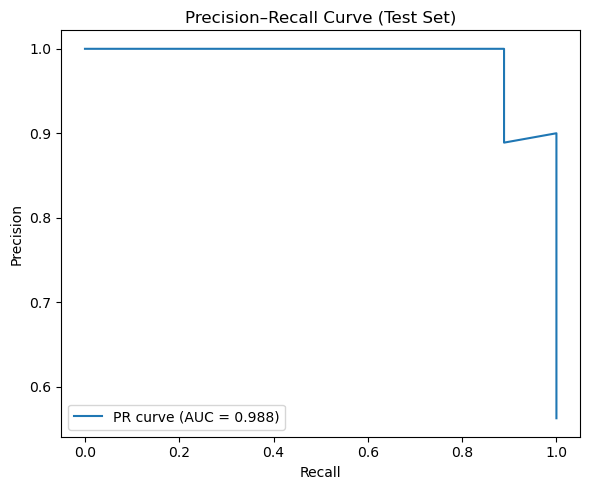

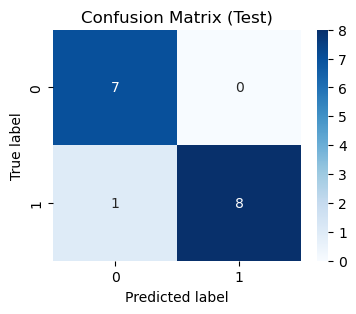

In [14]:
# Predictions
y_train_pred = best_lr.predict(X_train_scaled)
y_train_proba = best_lr.predict_proba(X_train_scaled)[:, 1]

y_test_pred = best_lr.predict(X_test_scaled)
y_test_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

def print_metrics(y_true, y_pred, y_proba, name):
    print(f"\n=== {name} METRICS ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))

print_metrics(y_train, y_train_pred, y_train_proba, "TRAIN")
print_metrics(y_test, y_test_pred, y_test_proba, "TEST")

from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)      # uses positive class probs [web:312][web:319]
roc_auc = auc(fpr, tpr)                                         # same as roc_auc_score for binary case [web:325]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Precision–Recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_proba)  # binary PR curve [web:311][web:323]
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Test Set)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


# Confusion Matrix 
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


## Feature importance 


Top 20 features by |coefficient| (strongest signal):
                          feature  coefficient  abs_coef
39            cog_pregame_anxiety      -0.3392    0.3392
25               demo_fin_support       0.3089    0.3089
21          hst_practice_hrs_band       0.3078    0.3078
37                       demo_edu       0.2846    0.2846
5           pull_ups_rel_impr_pct       0.2738    0.2738
6                     demo_income       0.2569    0.2569
11           weight_impr_per_year      -0.2562    0.2562
28             demo_sports_access       0.2476    0.2476
4               hst_game_hrs_band       0.2346    0.2346
41                      dash_10yd       0.2271    0.2271
17  flexed_arm_hang_impr_per_year      -0.2202    0.2202
7                       res_score       0.2082    0.2082
43                demo_race_black      -0.1968    0.1968
26       broad_jump_impr_per_year      -0.1949    0.1949
31                      grt_score      -0.1854    0.1854
48              cop_visualization 

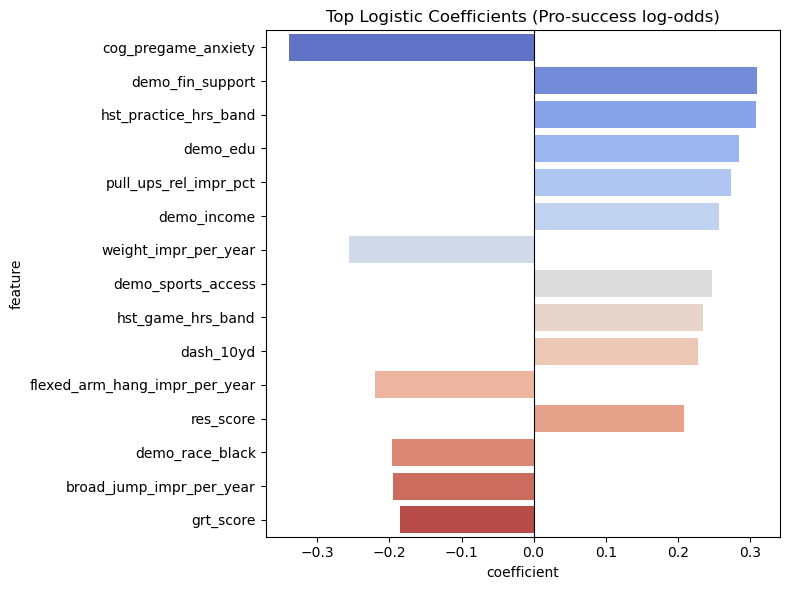

In [15]:
coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': best_lr.coef_[0]
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("\nTop 20 features by |coefficient| (strongest signal):")
print(coef_df.head(20).round(4))  # importance via coefficient magnitude [web:92][web:100]

plt.figure(figsize=(8, 6))
top_n = 15
sns.barplot(
    data=coef_df.head(top_n),
    x='coefficient', y='feature',
    palette='coolwarm'
)
plt.title('Top Logistic Coefficients (Pro-success log-odds)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## Model packing

In [16]:
import joblib

pipeline_objects = {
    'selector': selector,
    'scaler': scaler,
    'model': best_lr,
    'selected_features': selected_features,
    'coef_df': coef_df,
    'num_imputer': num_imputer,
    'num_features_full': num_features_full,
    'X_made_it_scaled': X_made_it_scaled,
    'made_it_ids': made_it_ids,
}


joblib.dump(pipeline_objects, "pro_success_pipeline.joblib")

print("Saved to pro_success_pipeline.joblib")


Saved to pro_success_pipeline.joblib
